=== Algorithmen Vergleich ===
RandomForest: 0.8324022346368715
Logistic Regression: 0.8044692737430168
KNN: 0.7486033519553073

=== Cross Validation ===
Einzelne Scores: [0.77653631 0.8258427  0.83146067 0.79775281 0.84269663]
Durchschnitt: 0.8148578243675851

=== Confusion Matrix ===


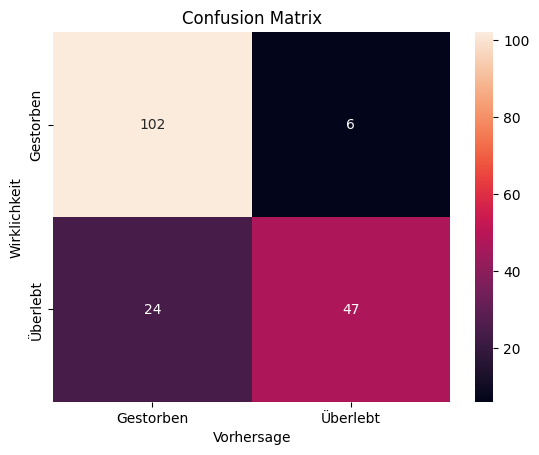


=== Classification Report ===
              precision    recall  f1-score   support

   Gestorben       0.81      0.94      0.87       108
    Überlebt       0.89      0.66      0.76        71

    accuracy                           0.83       179
   macro avg       0.85      0.80      0.81       179
weighted avg       0.84      0.83      0.83       179



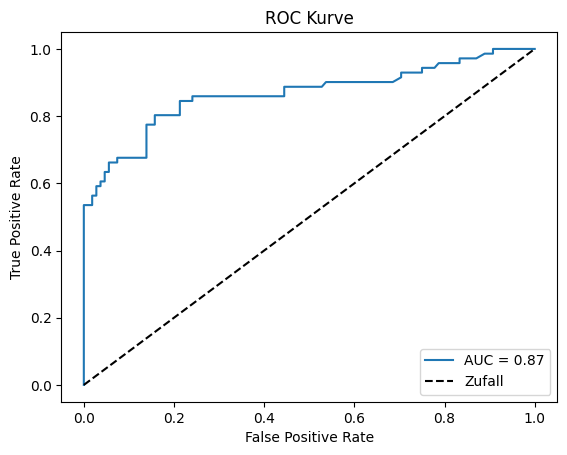

AUC Score: 0.8655451225873761


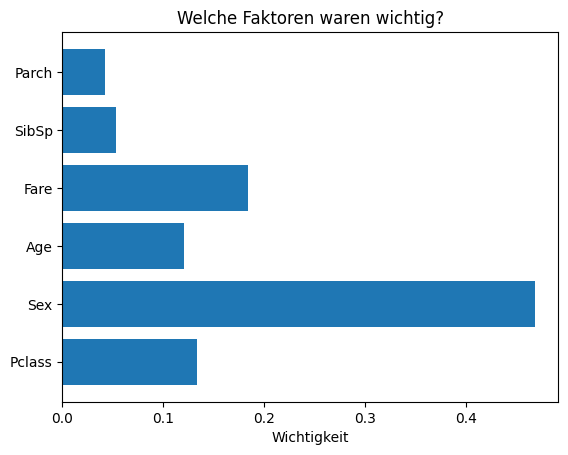


=== Pipeline Genauigkeit ===
0.8100558659217877
Pipeline gespeichert!
Vorhersage: Überlebt!


In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, roc_curve, auc, confusion_matrix

# Daten laden
df = pd.read_csv("/kaggle/input/competitions/titanic/train.csv")

# Data Cleaning
df["Age"] = df["Age"].fillna(df["Age"].median())
df["Sex"] = df["Sex"].map({"male": 0, "female": 1})

# ML Vorbereitung
X = df[["Pclass", "Sex", "Age", "Fare", "SibSp", "Parch"]]
y = df["Survived"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# Algorithmen vergleichen
print("=== Algorithmen Vergleich ===")
modell_rf = RandomForestClassifier(n_estimators=100, max_depth=5)
modell_rf.fit(X_train, y_train)
print("RandomForest:", modell_rf.score(X_test, y_test))

modell_lr = LogisticRegression()
modell_lr.fit(X_train, y_train)
print("Logistic Regression:", modell_lr.score(X_test, y_test))

modell_knn = KNeighborsClassifier(n_neighbors=5)
modell_knn.fit(X_train, y_train)
print("KNN:", modell_knn.score(X_test, y_test))

# Cross Validation
print("\n=== Cross Validation ===")
scores = cross_val_score(modell_rf, X, y, cv=5)
print("Einzelne Scores:", scores)
print("Durchschnitt:", scores.mean())

# Confusion Matrix
print("\n=== Confusion Matrix ===")
y_pred = modell_rf.predict(X_test)
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=["Gestorben", "Überlebt"],
            yticklabels=["Gestorben", "Überlebt"])
plt.title("Confusion Matrix")
plt.ylabel("Wirklichkeit")
plt.xlabel("Vorhersage")
plt.show()

# Classification Report
print("\n=== Classification Report ===")
print(classification_report(y_test, y_pred, target_names=["Gestorben", "Überlebt"]))

# ROC Kurve
y_prob = modell_rf.predict_proba(X_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_prob)
auc_score = auc(fpr, tpr)
plt.plot(fpr, tpr, label=f"AUC = {auc_score:.2f}")
plt.plot([0, 1], [0, 1], "k--", label="Zufall")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Kurve")
plt.legend(loc="lower right")
plt.show()
print("AUC Score:", auc_score)

# Feature Importance
feature_names = ["Pclass", "Sex", "Age", "Fare", "SibSp", "Parch"]
importance = modell_rf.feature_importances_
plt.barh(feature_names, importance)
plt.title("Welche Faktoren waren wichtig?")
plt.xlabel("Wichtigkeit")
plt.show()

# Pipeline
pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("modell", RandomForestClassifier(n_estimators=100, max_depth=5))
])
pipeline.fit(X_train, y_train)
print("\n=== Pipeline Genauigkeit ===")
print(pipeline.score(X_test, y_test))

# Pipeline speichern
joblib.dump(pipeline, "/kaggle/working/titanic_pipeline.pkl")
print("Pipeline gespeichert!")

# Pipeline laden und testen
pipeline_geladen = joblib.load("/kaggle/working/titanic_pipeline.pkl")
neuer_passagier = pd.DataFrame([{
    "Pclass": 1,
    "Sex": 1,
    "Age": 25,
    "Fare": 100,
    "SibSp": 0,
    "Parch": 0
}])
vorhersage = pipeline_geladen.predict(neuer_passagier)
print("Vorhersage:", "Überlebt!" if vorhersage[0] == 1 else "Nicht überlebt!")

In [32]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from sklearn.model_selection import train_test_split

df = pd.read_csv("/kaggle/input/competitions/titanic/train.csv")
df["Age"] = df["Age"].fillna(df["Age"].median())
df["Sex"] = df["Sex"].map({"male": 0, "female": 1})
X = df[["Pclass", "Sex", "Age", "Fare", "SibSp", "Parch"]]
y = df["Survived"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)
X_train_nn = np.array(X_train)
X_test_nn = np.array(X_test)

modell_nn = keras.Sequential([
    keras.layers.Dense(64, activation="relu", input_shape=(6,)),
    keras.layers.Dense(32, activation="relu"),
    keras.layers.Dense(1, activation="sigmoid")
])
modell_nn.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
history = modell_nn.fit(X_train_nn, y_train, epochs=50, batch_size=32,
                        validation_data=(X_test_nn, y_test), verbose=0)
verlust, genauigkeit = modell_nn.evaluate(X_test_nn, y_test, verbose=0)
print(f"Neuronales Netz Genauigkeit: {genauigkeit:.2%}")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Neuronales Netz Genauigkeit: 81.56%
